# Gravity–Capillary initial-value problem ( IVP ) 

This notebook implements a **self-contained**, readable version of the IVP for gravity–capillary waves in deep water. Every FFT and spectral operation is written explicitly using plain `FFTW.fft`/`FFTW.ifft` calls.

The IVP is evolved in a frame co-moving with the steady wave at speed $c$.
The computed surface profiles are compared against Basilisk VOF simulation
data from `/basilisk_gc_ivp/interface_data/`.

Physical parameters (CGS): $N = 1024$, $\varepsilon = 0.9$,
$c = 24$ cm/s, $T = 0.26$ (final-simulation time)s.

## 1. Conformal-mapping formulation

We work in the co-moving conformal frame where the spatial coordinate is
$\xi \in [-\tfrac{1}{2}, \tfrac{1}{2})$ and the unknowns are:

- $Y(\xi, t)$: free-surface elevation,
- $\varphi(\xi, t)$: velocity potential on the free surface.

The physical horizontal coordinate is recovered via the Hilbert transform:

$$
X_\xi = 1 - \mathcal{H}[Y_\xi], \qquad X_{\xi\xi} = -\mathcal{H}[Y_{\xi\xi}],
$$

and the Jacobian of the conformal map is

$$
J = X_\xi^2 + Y_\xi^2.
$$

The stream function on the surface satisfies $\psi_\xi = Y_\xi$ (kinematic
identity in the conformal plane), and $\varphi_\xi = -\mathcal{H}[\psi_\xi]$
by the Cauchy–Riemann relation.

## 2. Evolution equations

Define the normal velocity

$$
V = \frac{Y_\xi - \mathcal{H}[\varphi_\xi]}{J}.
$$

### Kinematic equation

$$
\frac{\partial Y}{\partial t} = X_\xi \, V - Y_\xi \, \mathcal{H}[V]
$$

### Dynamic (Bernoulli) equation

$$
\frac{\partial \varphi}{\partial t}
= \frac{\psi_\xi^2 - \varphi_\xi^2}{2J}
- \frac{Y}{F^2}
+ \frac{B}{F^2} \frac{X_\xi Y_{\xi\xi} - Y_\xi X_{\xi\xi}}{J^{3/2}}
+ \frac{X_\xi \varphi_\xi}{J}
- \varphi_\xi \, \mathcal{H}[V]
$$

where $\psi_\xi = \mathcal{H}[\varphi_\xi]$, $F$ is the Froude number,
and $B$ is the Bond number.

## 3. Setup

In [1]:
using FFTW
using OrdinaryDiffEq, OrdinaryDiffEqRosenbrock, LinearSolve
using NonlinearSolve
using Plots, LaTeXStrings, Printf
using DelimitedFiles

In [2]:
const N = 1024

ξ = [(-1/2) + j/N for j in 0:N-1]
k = [0:(N÷2)-1; 0; (-N÷2)+1:-1]
d = 2π * im .* k
h = im .* sign.(k);  h[1] = 0;  h[N÷2+1] = 0

# Readable spectral helpers (allocating, simple)
deriv(Y)         = real(ifft(d .* fft(Y)))
deriv2(Y)        = real(ifft(d.^2 .* fft(Y)))
hilbert(Y)       = real(ifft(h .* fft(Y)))
hilbert_deriv(Y) = real(ifft(h .* d .* fft(Y)))

function spectral_integrate(f)
    f̂ = fft(f);  F̂ = f̂ ./ d
    F̂[1] = 0;  F̂[N÷2+1] = 0
    return real(ifft(F̂))
end

# Composite Simpson weights on the endpoint-excluded uniform grid.
# These match the GravityProblem energy quadrature used for the Basilisk IC.
function simpson_weights_uniform(ξ)
    n = length(ξ)
    Δξ = ξ[2] - ξ[1]
    w = fill(2 * Δξ / 3, n)
    w[2:2:n-3] .= 4 * Δξ / 3
    w[1] = Δξ / 3
    w[n-2] = 5 * Δξ / 4
    w[n-1] = Δξ
    w[n] = 5 * Δξ / 12
    return w
end

simpson_w = simpson_weights_uniform(ξ)
simpson_integral(f) = sum(simpson_w .* f)

println("Grid: N=$N")

Grid: N=1024


## 4. Steady base state (pure gravity, B = 0)

Energy continuation from a linear seed to $\varepsilon = 0.9$.

In [3]:
const Ehw = 0.00184

# During the initial continuation B=0 exactly.  Avoid calculating GC
# curvature and second derivatives that make no contribution to this residual.
function gravity_residual!(du, u, ε)
    Y = u[1:N]
    F = u[end]
    F2 = F^2

    Yξ = deriv(Y)
    Xξ = 1.0 .- hilbert_deriv(Y)
    J = Xξ.^2 .+ Yξ.^2

    ψξ = Yξ
    ϕξ = -hilbert(ψξ)
    ϕ = spectral_integrate(ϕξ)
    ϕ .-= sum(ϕ .* Xξ) / sum(Xξ)

    for i in 1:N
        du[i] = -F2 * (Xξ[i] * ϕξ[i] + Yξ[i] * ψξ[i]) / J[i] +
                F2 * (ϕξ[i]^2 + ψξ[i]^2) / (2 * J[i]) + Y[i]
    end

    KE = (F2 / 2) * simpson_integral(-ϕ .* ψξ)
    PE = simpson_integral(Y.^2 .* Xξ) / 2
    du[N+1] = (KE + PE) / Ehw - ε
end

Y0 = 1e-5 .* cos.(2π .* ξ)
F0 = sqrt(1 / (2π))
u0_steady = vcat(Y0, F0)

ε_target = 0.9
# Same continuation schedule as the Basilisk generator's GravityProblem solve.
ε_schedule = Float64[]
ε = 1e-7
while ε < 1e-2
    push!(ε_schedule, ε)
    ε *= 2
end
append!(ε_schedule, 0.01:0.01:min(0.50, ε_target))
if ε_target > 0.50
    append!(ε_schedule, 0.52:0.02:ε_target)
end

println("Running pure-gravity energy continuation ($(length(ε_schedule)) steps) ...")
@time for (step, ε) in enumerate(ε_schedule)
    prob = NonlinearProblem(gravity_residual!, u0_steady, ε)
    sol = NonlinearSolve.solve(prob,
        NewtonRaphson(; autodiff=AutoFiniteDiff());
        abstol=1e-10, maxiters=100)
    global u0_steady = sol.u
    if step % 20 == 0 || step == length(ε_schedule)
        F_s = sol.u[end]
        kH2 = (maximum(sol.u[1:N]) - minimum(sol.u[1:N])) * π
        @printf("  step %3d: ε=%.2f, F=%.6f, kH/2=%.4f, %s\n",
            step, ε, F_s, kH2, sol.retcode)
    end
end

Y_steady = u0_steady[1:N]
F_steady = u0_steady[end]
@printf("Steady state: F = %.10f, kH/2 = %.6f\n", F_steady, (maximum(Y_steady) - minimum(Y_steady)) * π)

Running pure-gravity energy continuation (87 steps) ...
  step  20: ε=0.03, F=0.399814, kH/2=0.0661, Success
  step  40: ε=0.23, F=0.405740, kH/2=0.1838, Success
  step  60: ε=0.43, F=0.411926, kH/2=0.2531, Success
  step  80: ε=0.76, F=0.423151, kH/2=0.3436, Success
  step  87: ε=0.90, F=0.428749, kH/2=0.3808, Success
 79.012695 seconds (6.00 G allocations: 164.960 GiB, 8.33% gc time, 0.97% compilation time)
Steady state: F = 0.4287490973, kH/2 = 0.380809


## 5. Physical parameters and initial condition

We fix $c = 24$ cm/s to match the Basilisk comparison data.

In [4]:
const g_cgs  = 981.0
const σ_cgs  = 72.0
const ρ_cgs  = 1.0
const c_cgs  = 24.0

λ_cm  = c_cgs^2 / (F_steady^2 * g_cgs)
B_ivp = σ_cgs / (ρ_cgs * g_cgs * λ_cm^2)

@printf("F = %.10f\n", F_steady)
@printf("λ = %.6f cm\n", λ_cm)
@printf("B = %.10f\n", B_ivp)
@printf("c = %.1f cm/s\n", c_cgs)

# Reconstruct ϕ from the steady kinematic relation
ϕξ_steady = -hilbert(deriv(Y_steady))
ϕ_steady  = spectral_integrate(ϕξ_steady)
Xξ_steady = 1.0 .- hilbert_deriv(Y_steady)
ϕ_steady .-= sum(ϕ_steady .* Xξ_steady) / sum(Xξ_steady)

u0_ivp = vcat(Y_steady, ϕ_steady)
println("IVP state: 2×$N = $(length(u0_ivp))")

F = 0.4287490973
λ = 3.194089 cm
B = 0.0071939831
c = 24.0 cm/s
IVP state: 2×1024 = 2048


## 6. ODE right-hand side

Readable, allocating RHS.  Every line corresponds to the equations in §2.

In [5]:
function gc_rhs!(du, u, p, t)
    F, B = p
    Y = u[1:N];  ϕ = u[N+1:2N]

    Yξ   = deriv(Y)
    Yξξ  = deriv2(Y)
    Xξ   = 1.0 .- hilbert_deriv(Y)
    Xξξ  = -hilbert(deriv2(Y))
    J    = Xξ.^2 .+ Yξ.^2

    ϕξ  = deriv(ϕ)
    ψξ  = hilbert(ϕξ)

    V  = (Yξ .- ψξ) ./ J
    HV = hilbert(V)

    # Kinematic
    du[1:N] .= Xξ .* V .- Yξ .* HV

    # Dynamic
    F2 = F^2
    curvature = (Xξ .* Yξξ .- Yξ .* Xξξ) ./ J.^(3/2)
    du[N+1:2N] .= (ψξ.^2 .- ϕξ.^2) ./ (2 .* J) .-
        Y ./ F2 .+ (B / F2) .* curvature .+
        Xξ .* ϕξ ./ J .- ϕξ .* HV
end

gc_rhs! (generic function with 1 method)

## 7. Time integration

In [15]:
T_phys   = 0.26     # s
Δt_save  = 0.01     # s
τ_per_s  = c_cgs / λ_cm
τ_final  = τ_per_s * T_phys
τ_save   = τ_per_s .* collect(0:Δt_save:T_phys)
t_phys   = collect(0:Δt_save:T_phys)

println("Integrating for $T_phys s ($(length(τ_save)) snapshots) ...")

f_ivp = ODEFunction(gc_rhs!)
prob  = ODEProblem(f_ivp, u0_ivp, (0.0, τ_final), (F_steady, B_ivp))

@time sol = solve(prob,  ROK4a(autodiff=AutoFiniteDiff(), linsolve=KrylovJL());
    saveat=τ_save, abstol=1e-11, reltol=1e-11, maxiters=10^7)

println("Solver: $(sol.retcode), $(length(sol.u)) snapshots")

Integrating for 0.26 s (27 snapshots) ...
904.539211 seconds (1.33 G allocations: 2.845 TiB, 10.40% gc time)
Solver: Success, 27 snapshots


## 8. Load direct Basilisk interface facets

The native Basilisk `output_facets()` files are read directly from
`scripts/basilisk_gc_init/interface_data/interface-<index>.dat`.
Each nonblank line is a PLIC facet endpoint `(x, y)`; blank lines separate facets.
They are plotted as adaptive-grid endpoint scatter points without profile resampling.

In [20]:
basilisk_interface_dir = joinpath(@__DIR__, "basilisk_gc_ivp", "interface_data")

function read_basilisk_facet_endpoints(path::AbstractString)
    endpoints = NTuple{2, Float64}[]
    for raw in eachline(path)
        line = strip(raw)
        isempty(line) && continue
        values = split(line)
        length(values) == 2 || error("Invalid Basilisk facet line in $path: $raw")
        push!(endpoints, (parse(Float64, values[1]), parse(Float64, values[2])))
    end
    isempty(endpoints) && error("No Basilisk facet endpoints in $path")
    return endpoints
end

basilisk_endpoints = Dict{Int, Vector{NTuple{2, Float64}}}()
for idx in 0:length(t_phys)-1
    path = joinpath(basilisk_interface_dir, "interface-$idx.dat")
    if isfile(path)
        basilisk_endpoints[idx] = read_basilisk_facet_endpoints(path)
    end
end

println("Loaded $(length(basilisk_endpoints)) direct Basilisk facet snapshots")

Loaded 27 direct Basilisk facet snapshots


## 9. Conformal IVP versus direct Basilisk interfaces

The GIF overlays the conformal IVP solution (blue) with the native Basilisk
PLIC facet endpoints (red) from `interface_data/interface-<index>.dat`.
Both sources are matched by snapshot index and physical time.

In [21]:
function surface_lab(u, t_s)
    Y = u[1:N]
    x_co = λ_cm .* (ξ .- hilbert(Y))
    return x_co .+ c_cgs * t_s, λ_cm .* Y
end

# Axis limits across all frames
ymin = minimum(minimum(surface_lab(u, t)[2]) for (u, t) in zip(sol.u, t_phys))
ymax = maximum(maximum(surface_lab(u, t)[2]) for (u, t) in zip(sol.u, t_phys))
ypad = max(0.1 * (ymax - ymin), 1e-4)

0.04176588181293796

┌ Info: Saved animation to /Users/nikhil/dev/InterfacialWaves.jl/scripts/gc_ivp_comparison.gif
└ @ Plots /Users/nikhil/.julia/packages/Plots/h49MV/src/animation.jl:156


Plots.AnimatedGif("/Users/nikhil/dev/InterfacialWaves.jl/scripts/gc_ivp_comparison.gif")
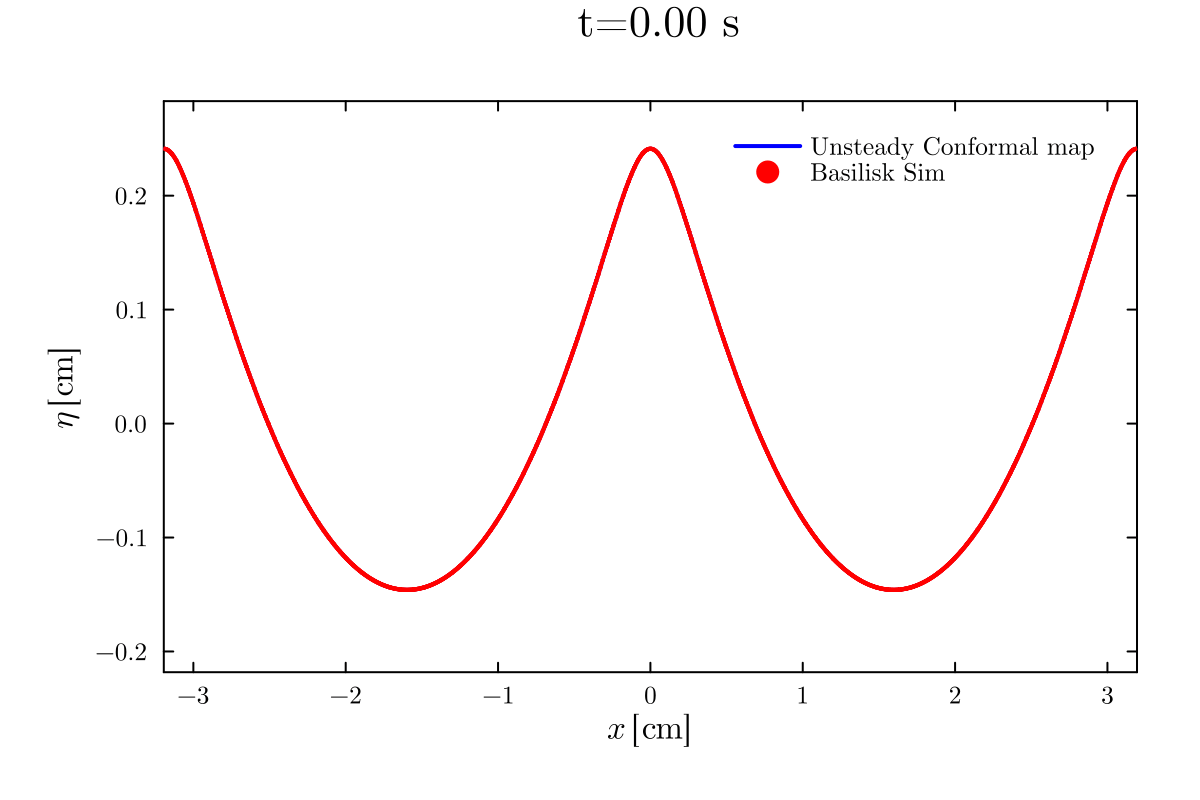

In [22]:
plot_font = "Computer Modern"
default( fontfamily=plot_font, dpi=200,  margin=6Plots.mm,
    linewidth=2, framestyle=:box, grid=false,  fg_legend=false, background_color_legend=false,
)

anim = @animate for (frame, (u, t_s)) in enumerate(zip(sol.u, t_phys))
    idx = frame - 1
    x, y = surface_lab(u, t_s)

    # The window [-λ, λ] contains two physical wavelengths.
    p = plot(
        ;
        xlims=(-λ_cm, λ_cm),
        ylims=(ymin - ypad, ymax + ypad),
        xlabel=L"x \; [\mathrm{cm}]",
        ylabel=L"\eta \; [\mathrm{cm}]",
        title=@sprintf(" t=%.2f s", t_s),
        legend=:topright,
    )

    # Conformal solution: periodic extension of one computed wavelength.
    for m in -2:2
        plot!(p, x .+ m * λ_cm, y;
            color=:blue, linewidth=2,
            label=(m == -2 ? "Unsteady Conformal map" : false))
    end

    # Native Basilisk PLIC facet endpoints: direct adaptive-grid data,
    # rendered without reconstructing or resampling an interface profile.
    if haskey(basilisk_endpoints, idx)
        endpoints = basilisk_endpoints[idx]
        scatter!(p, [point[1] for point in endpoints], [point[2] for point in endpoints];
            color=:red, markersize=1.2, markerstrokewidth=0,
            label="Basilisk Sim")
    end

    p
end

gif(anim, "gc_ivp_comparison.gif"; fps=5)
#println("Saved gc_ivp_comparison.gif")
